In [2]:
import pandas as pd

In [3]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
val = pd.read_csv('val.csv')

In [4]:
train.head()

,id_code,diagnosis
0,1ae8c165fd53,2
1,1b329a127307,1
2,1b32e1d775ea,4
3,1b3647865779,0
4,1b398c0494d1,0


In [5]:
test.head()

,id_code,diagnosis
0,e4dcca36ceb4,0
1,e4e343eaae2a,2
2,e4f12411fd85,4
3,e50b0174690d,0
4,e5197d77ec68,0


In [6]:
val.head()

,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


In [17]:
train_classes = []
test_classes = []
val_classes = []

def count_class(dataset, dataset_name):
    print(f"*** {dataset_name} Counting ***")
    print(f"-"*30)

    for i in range(0, 5):
        cls = dataset[dataset['diagnosis'] == i]

        if (dataset_name == "Train Data"):
            train_classes.append(cls.shape[0])
        elif (dataset_name == "Test Data"):
            test_classes.append(cls.shape[0])
        elif (dataset_name == "Validation Data"):
            val_classes.append(cls.shape[0])

        print(f"Class {i} = {cls.shape[0]}")

    print(f"Total {dataset_name} = {dataset.shape[0]}")
    print(f"-"*30)


In [18]:
count_class(train, "Train Data")
count_class(test, "Test Data")
count_class(val, "Validation Data")
print(f"Total Number of Images = {train.shape[0] + test.shape[0] + val.shape[0]}")

*** Train Data Counting ***
------------------------------
Class 0 = 1434
Class 1 = 300
Class 2 = 808
Class 3 = 154
Class 4 = 234
Total Train Data = 2930
------------------------------
*** Test Data Counting ***
------------------------------
Class 0 = 199
Class 1 = 30
Class 2 = 87
Class 3 = 17
Class 4 = 33
Total Test Data = 366
------------------------------
*** Validation Data Counting ***
------------------------------
Class 0 = 172
Class 1 = 40
Class 2 = 104
Class 3 = 22
Class 4 = 28
Total Validation Data = 366
------------------------------
Total Number of Images = 3662


In [20]:
print(train_classes)
print(test_classes)
print(val_classes)



[1434, 300, 808, 154, 234]
[199, 30, 87, 17, 33]
[172, 40, 104, 22, 28]


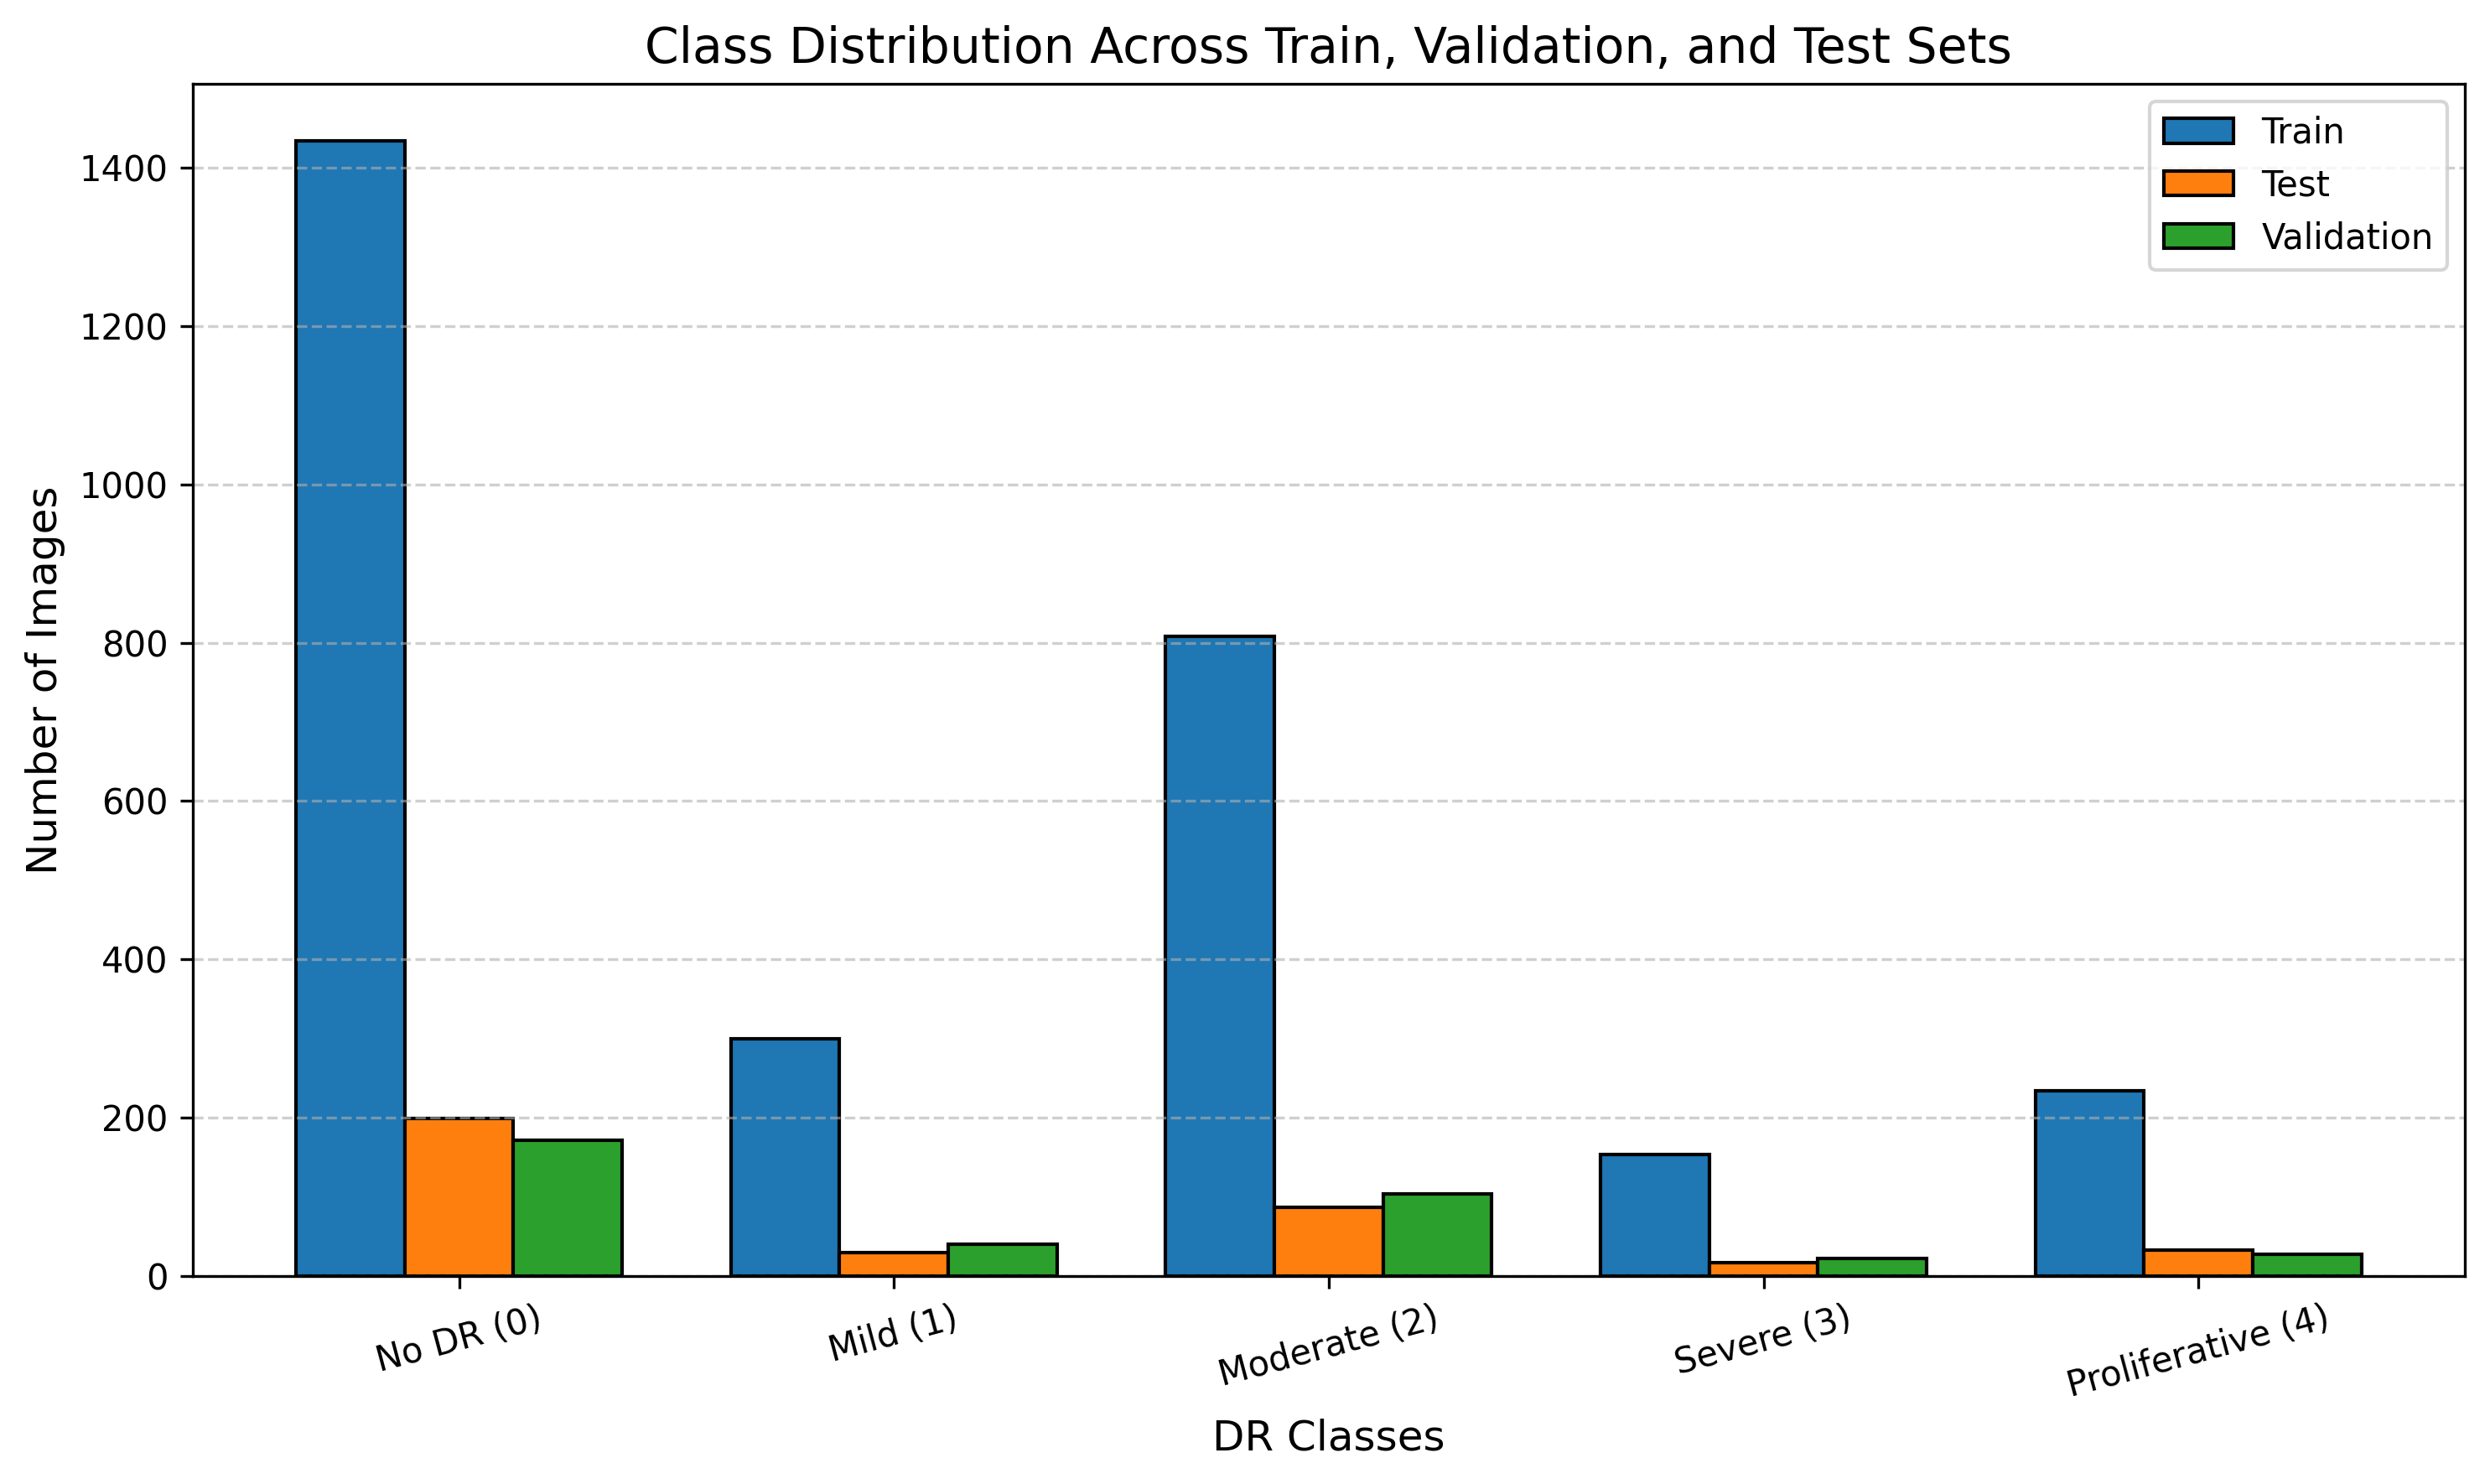

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Class labels
classes = ['No DR (0)', 'Mild (1)', 'Moderate (2)', 'Severe (3)', 'Proliferative (4)']


x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(10,6), dpi=300)

# Bars
plt.bar(x - width, train_classes, width, label='Train', edgecolor='black')
plt.bar(x, test_classes, width, label='Test', edgecolor='black')
plt.bar(x + width, val_classes, width, label='Validation', edgecolor='black')

# Labels
plt.xlabel('DR Classes', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Class Distribution Across Train, Validation, and Test Sets', fontsize=14)

plt.xticks(x, classes, rotation=15)
plt.legend()

# Grid (subtle, paper-style)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()

# Save (VERY IMPORTANT for paper)
plt.savefig('class_distribution_bar.png', dpi=600)
plt.show()

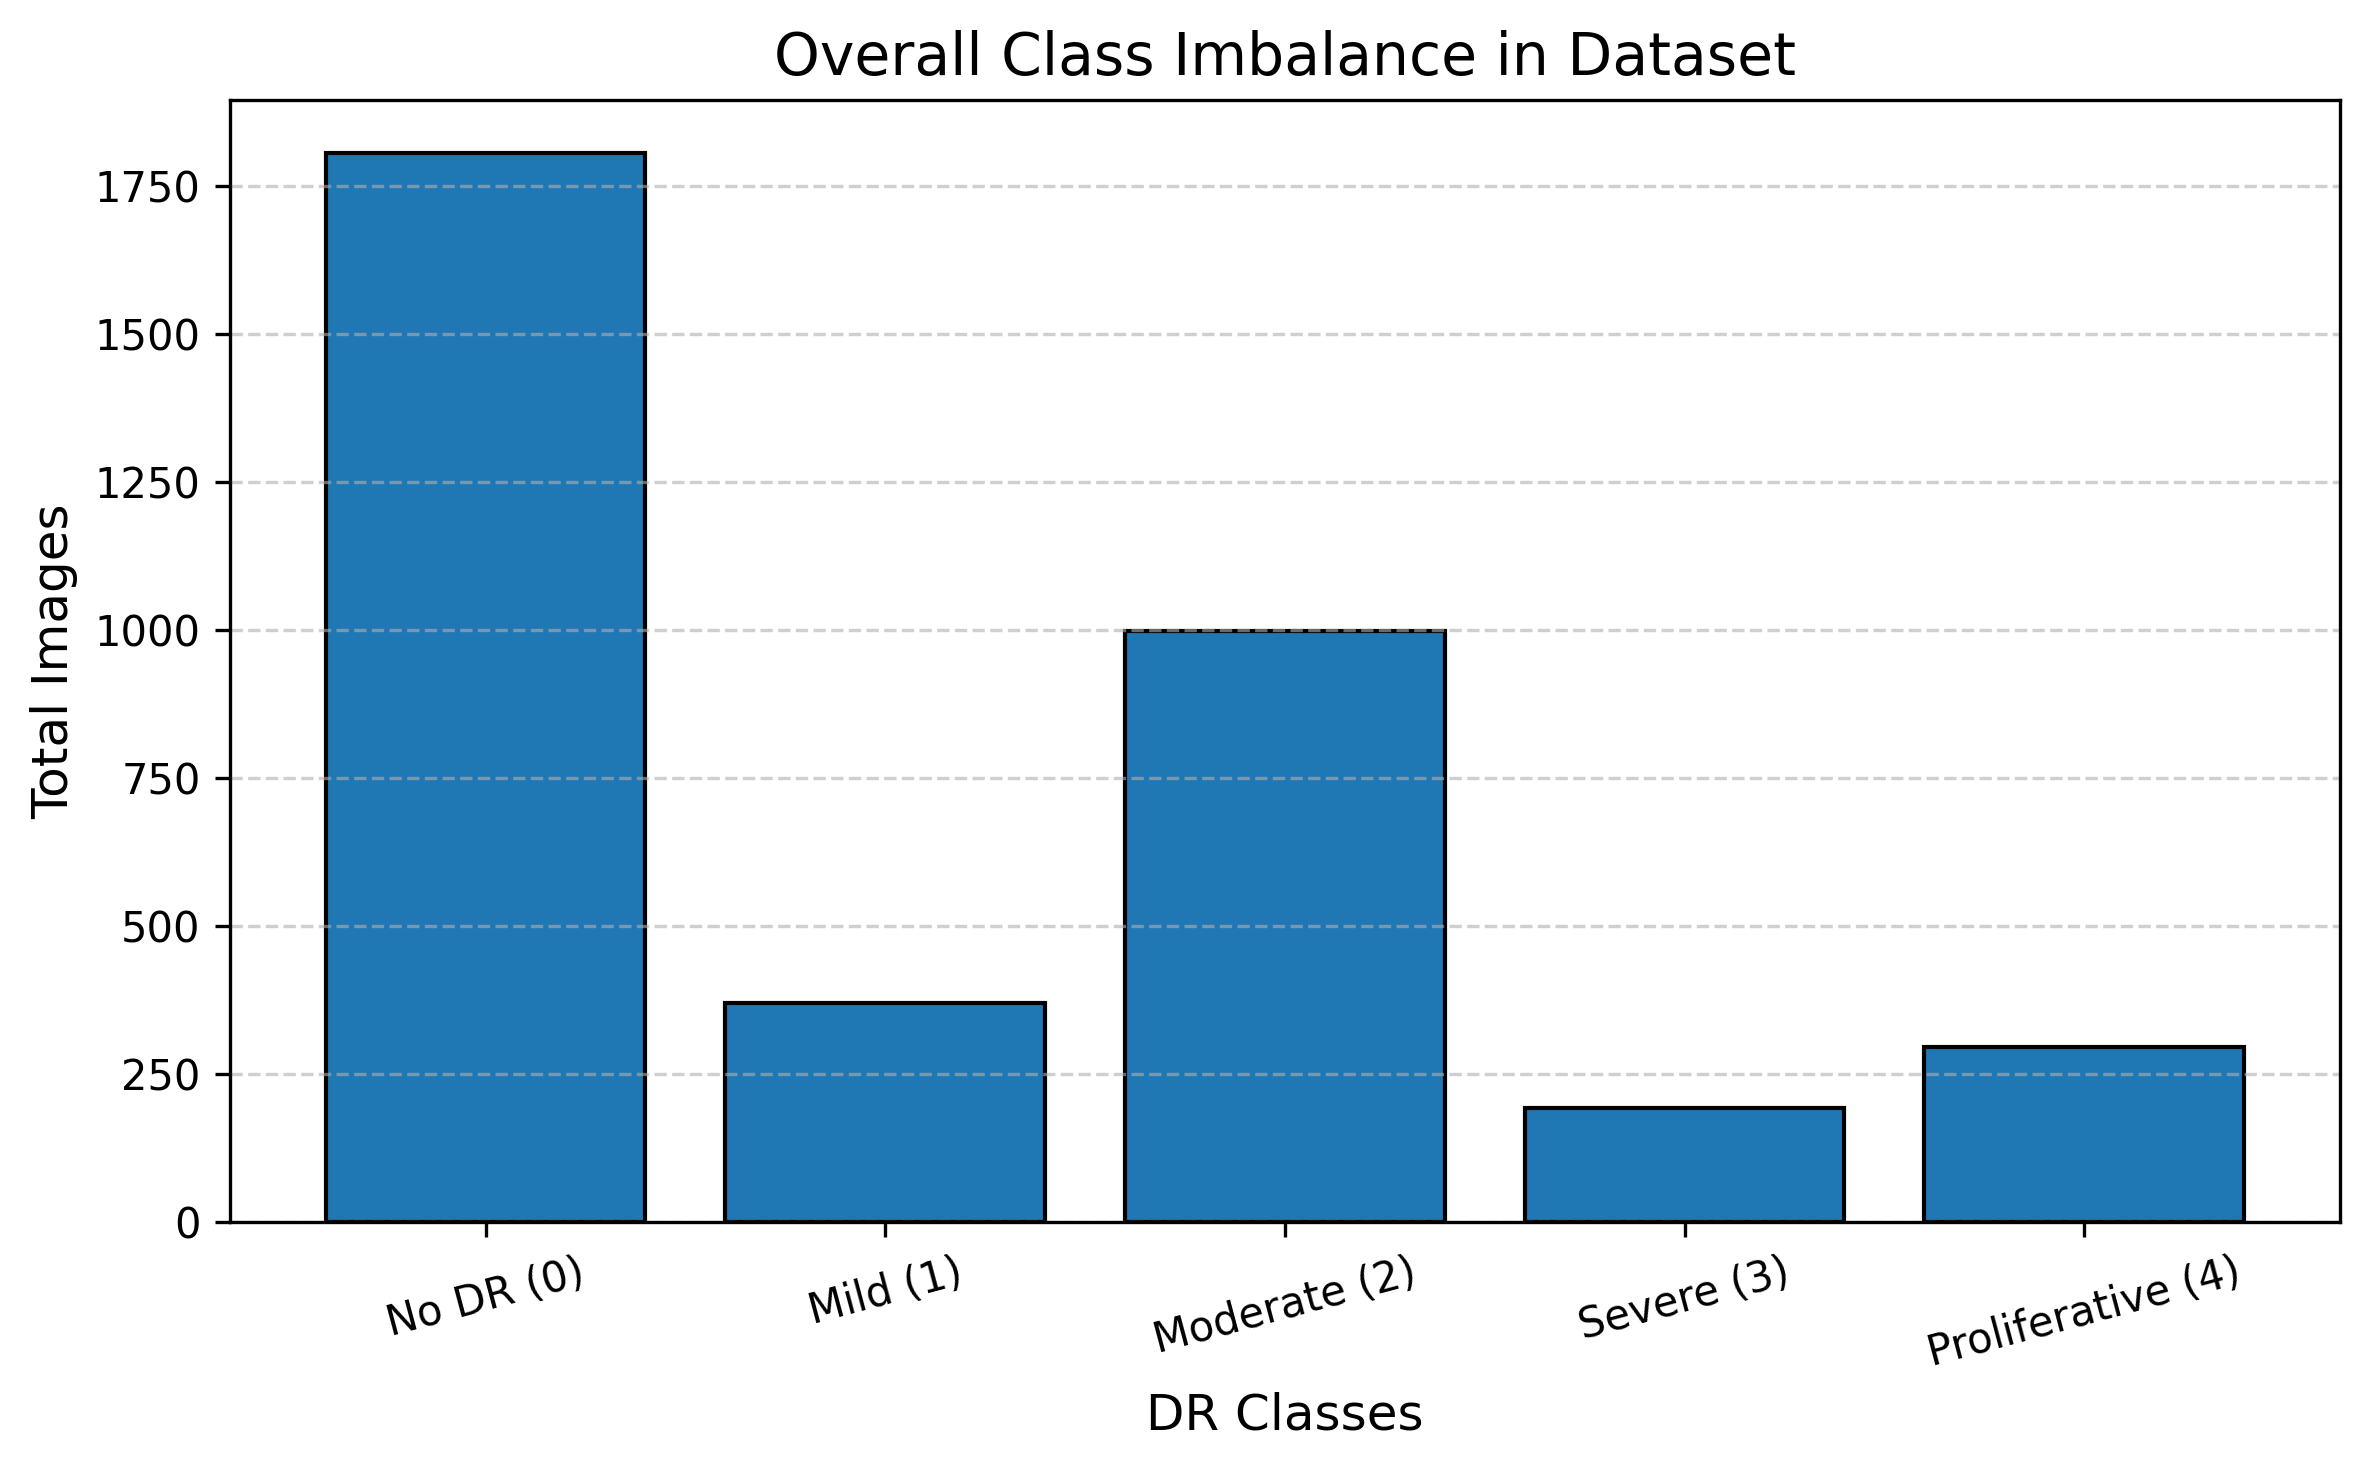

In [22]:
total = np.array(train_classes) + np.array(test_classes) + np.array(val_classes)

plt.figure(figsize=(8,5), dpi=300)

plt.bar(classes, total, edgecolor='black')

plt.xlabel('DR Classes', fontsize=12)
plt.ylabel('Total Images', fontsize=12)
plt.title('Overall Class Imbalance in Dataset', fontsize=14)

plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('total_class_distribution.png', dpi=600)
plt.show()

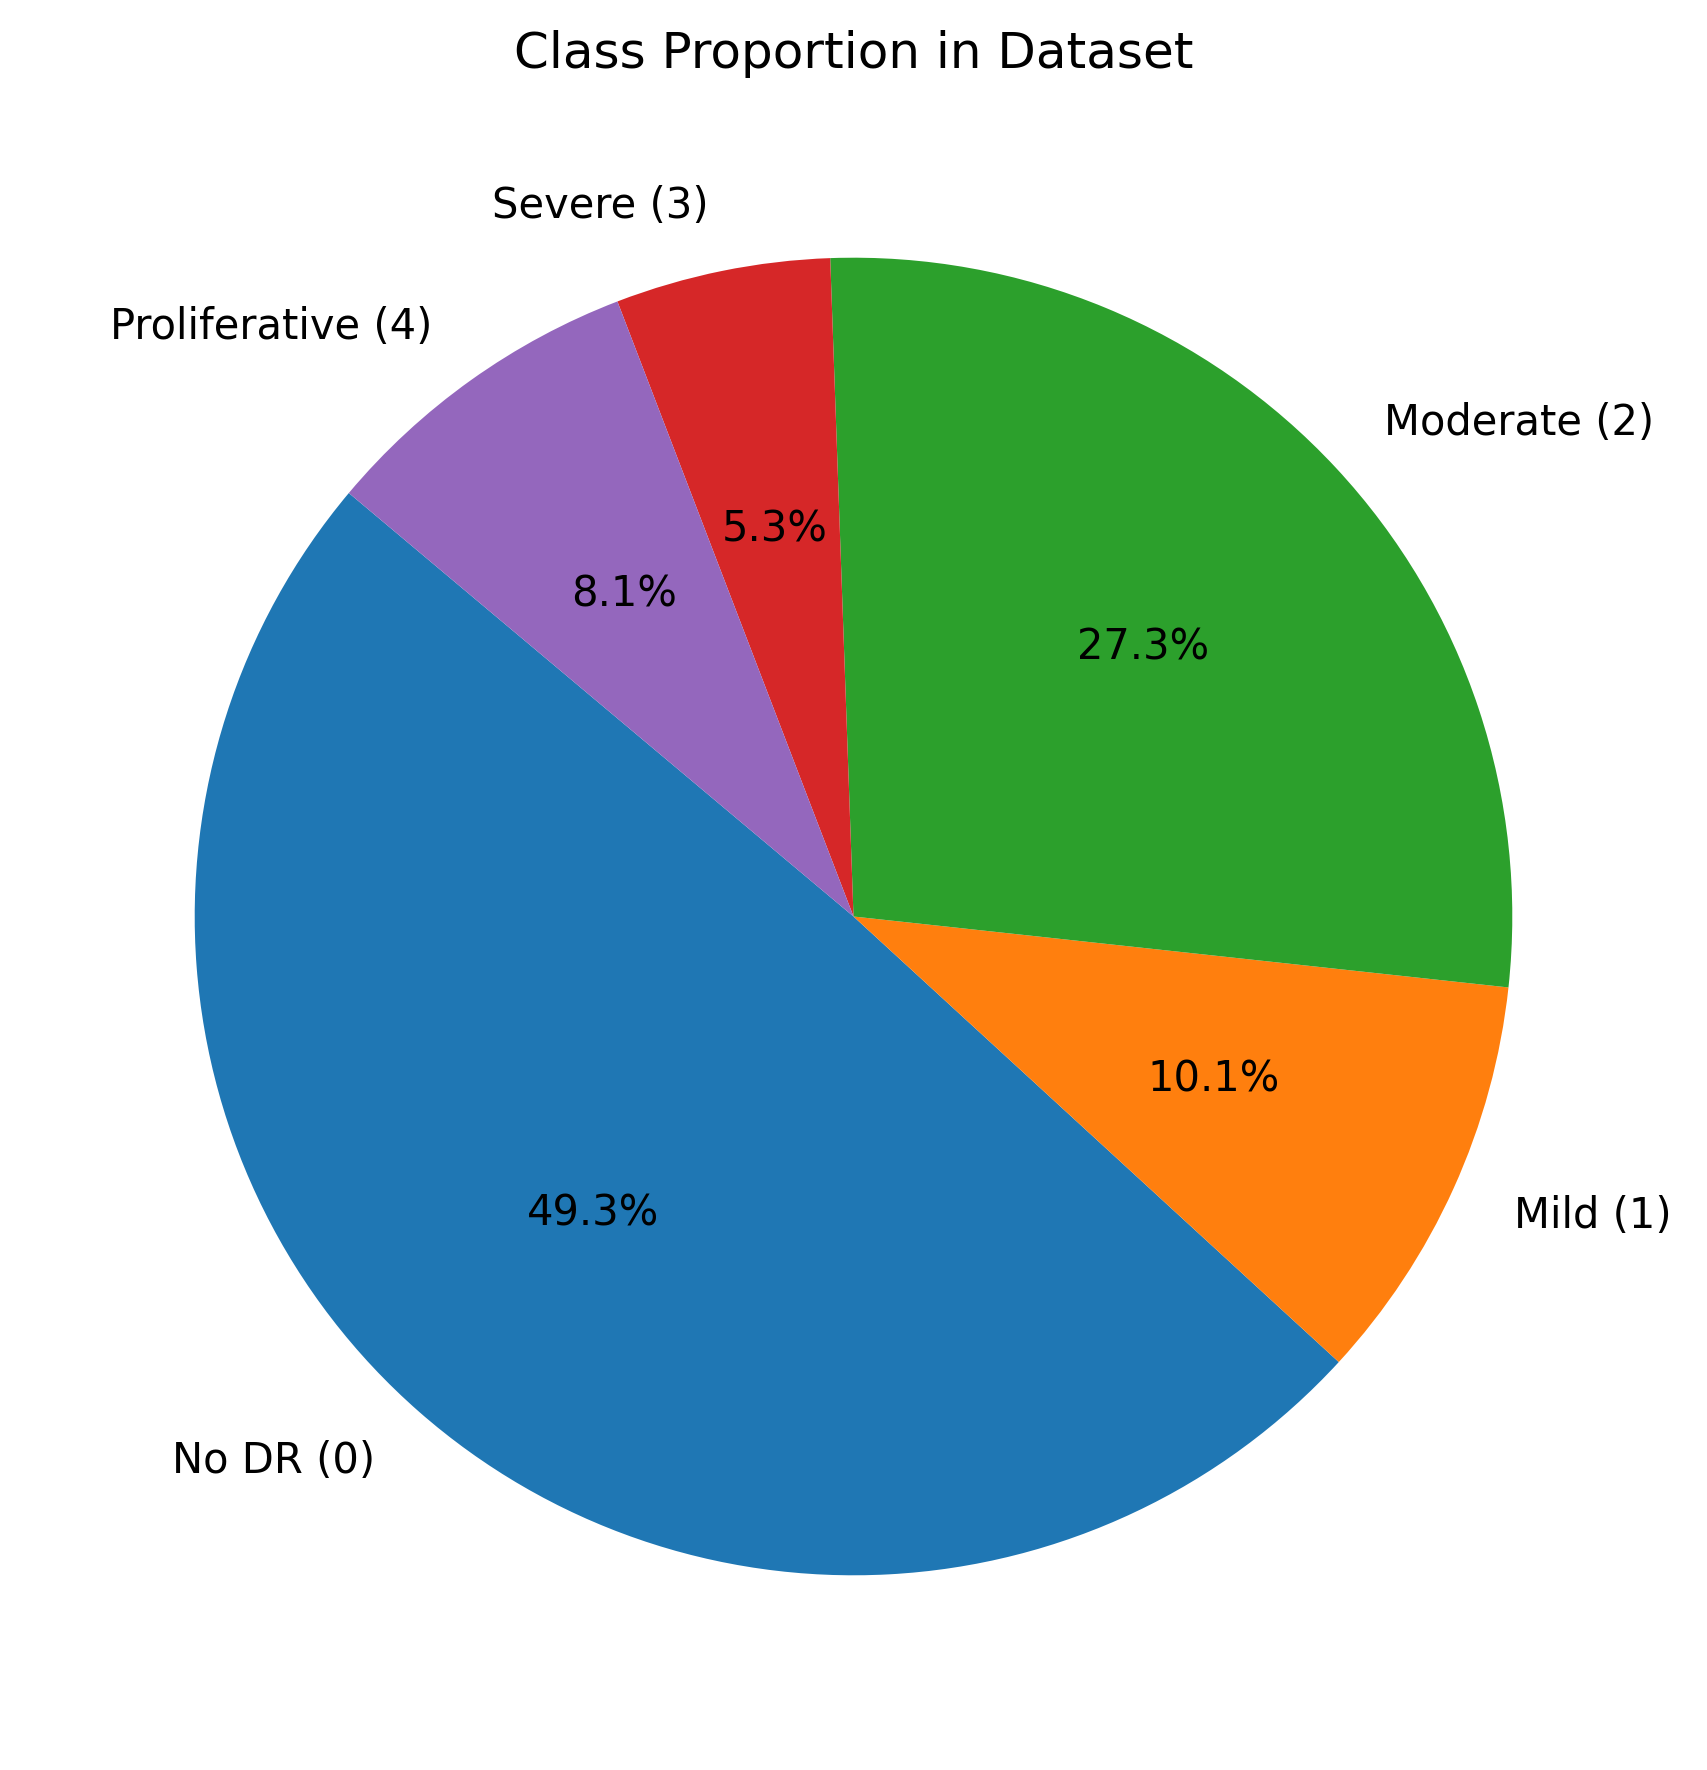

In [23]:
plt.figure(figsize=(6,6), dpi=300)

plt.pie(total, labels=classes, autopct='%1.1f%%', startangle=140)

plt.title('Class Proportion in Dataset')

plt.tight_layout()
plt.savefig('class_distribution_pie.png', dpi=600)
plt.show()

In [24]:
imbalance_ratio = max(total) / min(total)
print("Imbalance Ratio:", imbalance_ratio)

Imbalance Ratio: 9.352331606217616
